# CHUQ corpus: neutron ay

The CHUQ corpus is a reconstruction of the experimental data used in the CH89 global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Neutron analyzing powers, dimensionless, against CM scattering angle.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/chuq_neutron_ay.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('chuq', 'neutron_ay')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

11 rows, 5 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,chuq,neutron_ay,neutron,40,20,40Ca,10.935,None,12996004,,21
1,chuq,neutron_ay,neutron,40,20,40Ca,13.904,None,12996004,,21
2,chuq,neutron_ay,neutron,40,20,40Ca,16.923,None,12996004,,21
3,chuq,neutron_ay,neutron,58,28,58Ni,9.920,None,12930010,,21
4,chuq,neutron_ay,neutron,58,28,58Ni,13.910,None,12930010,,21
5,chuq,neutron_ay,neutron,116,50,116Sn,9.907,None,13158002,,21
6,chuq,neutron_ay,neutron,116,50,116Sn,13.894,None,13158002,,21
7,chuq,neutron_ay,neutron,120,50,120Sn,9.906,None,13158003,,21
8,chuq,neutron_ay,neutron,120,50,120Sn,13.894,None,13158003,,21
9,chuq,neutron_ay,neutron,208,82,208Pb,9.970,None,12844007,,21


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('chuq', 'neutron_ay')
print(result.summary())

chuq/neutron_ay
  spec rows              11
  ... marked absent      0
  ... resolved           11 / 11 (100.0%)
  measurements           11
  data points            232
  EXFOR entries          4
  serialized             11 measurements, 232 points


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

all spec rows resolved


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Every parsed data set is plotted, one figure per target, grouped by incident energy and
offset for legibility. Outliers here are found by eye: a mistranscribed point shows up
as a single datum an order of magnitude away from its neighbours; a badly normalised
data set shows up as a whole curve offset from others at the same energy. Nothing is
sampled or truncated -- the count of plotted data sets is checked against the number
written below, because a data set that is never drawn is one whose outliers are never
found.

plotted all 11 data sets


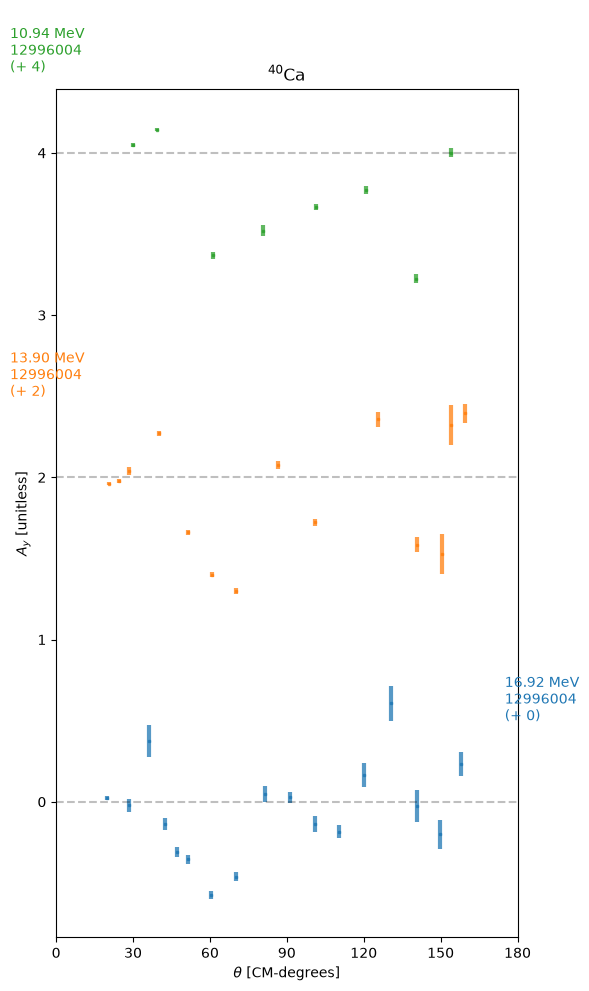

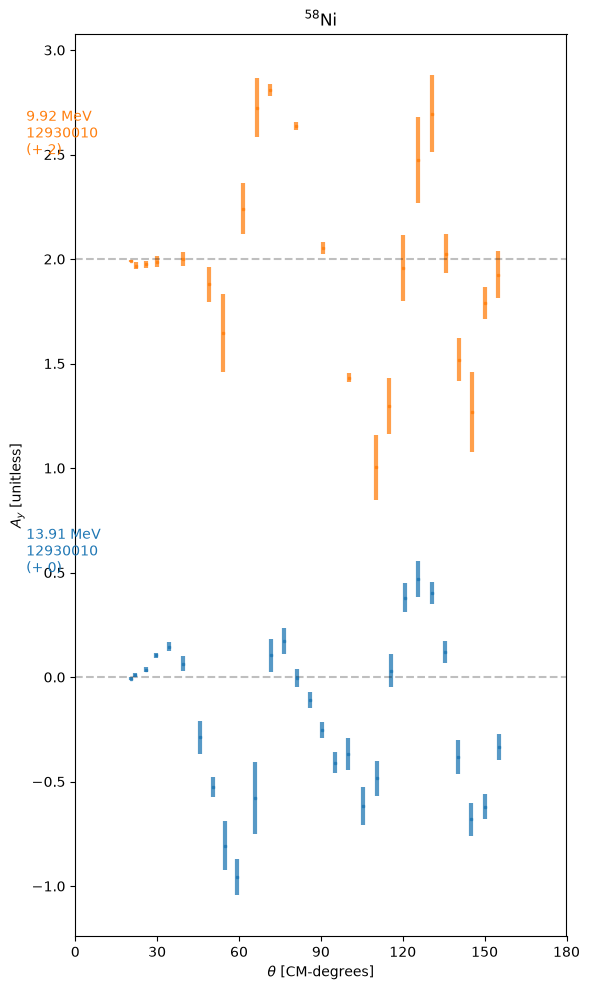

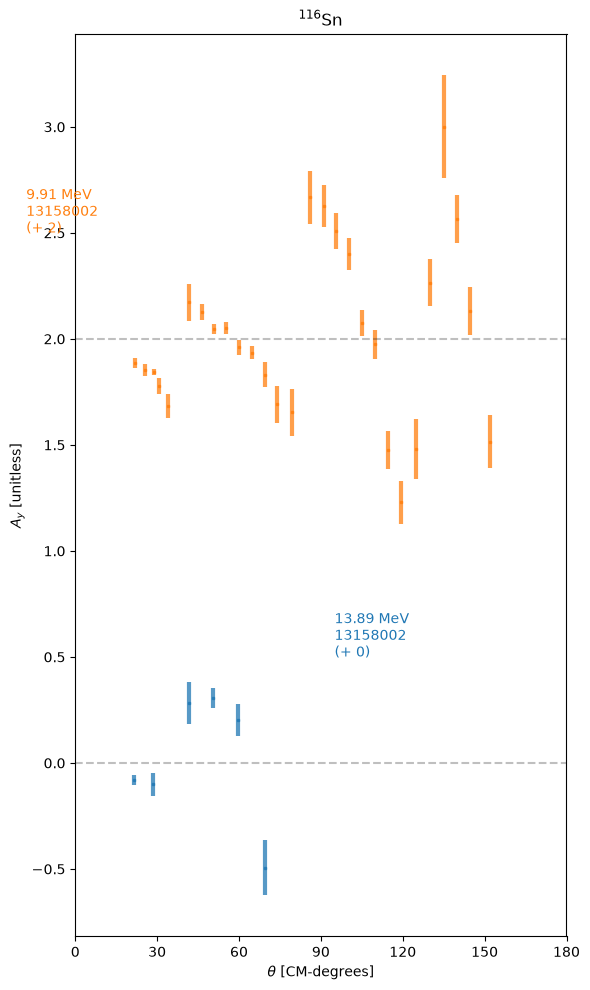

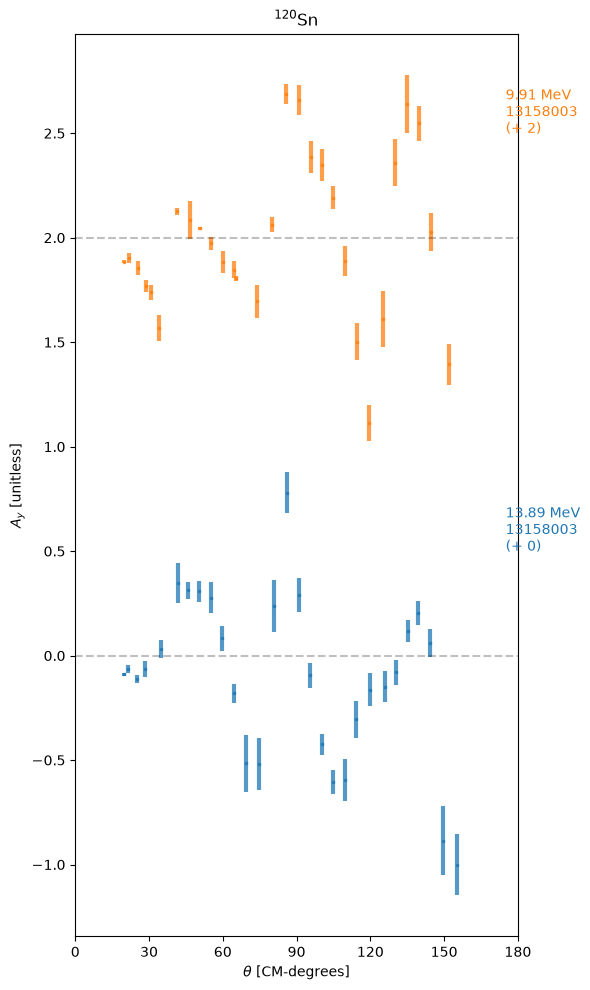

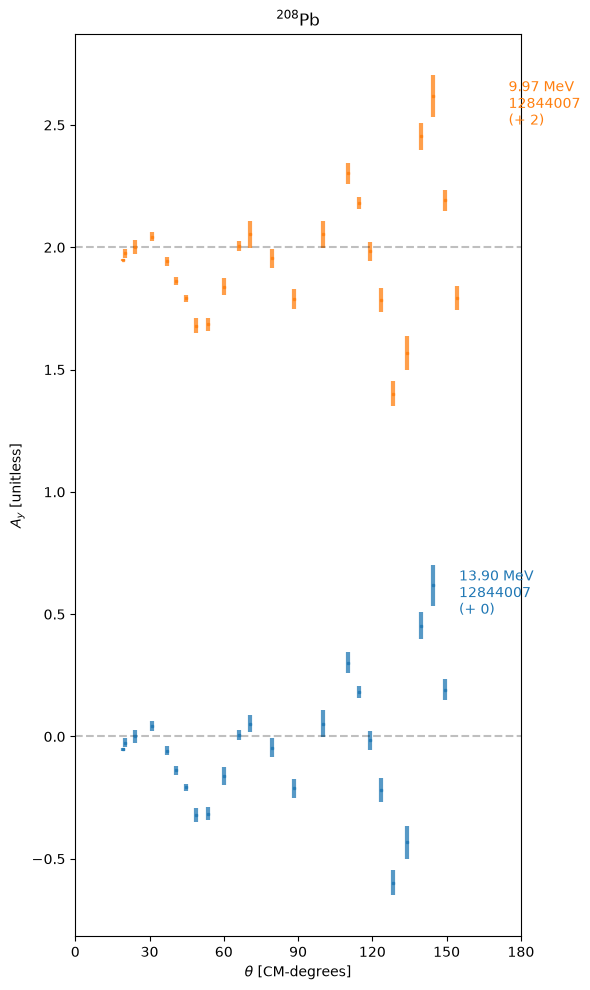

In [6]:
n_plotted = plotting.plot_sector(result)
assert n_plotted == len(result.records), (
    f"{len(result.records) - n_plotted} of {len(result.records)} data sets were not plotted")
print(f"plotted all {n_plotted} data sets")
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 11 measurements to data/chuq/neutron_ay/
